In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/Yersolid07/meeting_transcriber.git meeting_transcriber
%cd meeting_transcriber

Cloning into 'meeting_transcriber'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (224/224), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 224 (delta 66), reused 218 (delta 62), pack-reused 0 (from 0)
Receiving objects: 100% (224/224), 11.46 MiB | 15.28 MiB/s, done.
Resolving deltas: 100% (66/66), done.
Filtering content: 100% (8/8), 924.72 MiB | 13.56 MiB/s, done.
/content/meeting_transcriber


In [ ]:
# system deps
!apt-get update -y
!apt-get install -y ffmpeg sox libsndfile1

# Torch + Torchaudio (sesuaikan CUDA: cu118 umum di Colab)
!pip install --upgrade pip
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118

# repo deps
!pip install -r requirements.txt

# tambahan yang sering diperlukan
!pip install speechbrain huggingface_hub

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,315 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:13 http://security.ubuntu.com/ub

In [ ]:
import os
os.environ['HF_HUB_DISABLE_SYMLINKS'] = '1'
# opsional: arahkan cache/saved models ke Drive agar persisten
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

In [ ]:
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    A token is already saved on your machine. Run `hf auth whoami` to get more information or `hf auth logout` if you want to log out.
    Setting a new token will erase the existing one.
    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add t

In [ ]:
# pastikan file audio ada di repo atau di Drive
!python main.py --audio data/sample_audio/kondisi_multispeaker/rapatsingkat.mp3 --output ./output --evaluate --reference data/ground_truth/rapatsingkat_gt.txt --reference-rttm data/ground_truth/rapatsingkat_vibevoice.rttm --reference-summary data/rapatsingkat_reference_summary.txt

Traceback (most recent call last):
  File "/content/meeting_transcriber/main.py", line 29, in <module>
    from src.evaluator import EvaluationResult, Evaluator
  File "/content/meeting_transcriber/src/__init__.py", line 30, in <module>
    from src.audio_processor import AudioConfig, AudioProcessor
  File "/content/meeting_transcriber/src/audio_processor.py", line 14, in <module>
    import torch
  File "/usr/local/lib/python3.12/dist-packages/torch/__init__.py", line 427, in <module>
    from torch._C import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 463, in _lock_unlock_module
KeyboardInterrupt
^C


In [ ]:
!python main.py --audio data/sample_audio//kondisi_multispeaker/rapatsingkat.mp3 --evaluate --reference data/ground_truth/rapatsingkat_gt.txt --reference-rttm data/ground_truth/rapatsingkat_vibevoice.rttm --reference-summary data/ground_truth/rapatsingkat_reference_summary.txt --diarization-compare --output /output


╔══════════════════════════════════════════════════════════════════╗
║                                                                  ║
║   ███╗   ███╗███████╗███████╗████████╗██╗███╗   ██╗ ██████╗     ║
║   ████╗ ████║██╔════╝██╔════╝╚══██╔══╝██║████╗  ██║██╔════╝     ║
║   ██╔████╔██║█████╗  █████╗     ██║   ██║██╔██╗ ██║██║  ███╗    ║
║   ██║╚██╔╝██║██╔══╝  ██╔══╝     ██║   ██║██║╚██╗██║██║   ██║    ║
║   ██║ ╚═╝ ██║███████╗███████╗   ██║   ██║██║ ╚████║╚██████╔╝    ║
║   ╚═╝     ╚═╝╚══════╝╚══════╝   ╚═╝   ╚═╝╚═╝  ╚═══╝ ╚═════╝     ║
║                                                                  ║
║          TRANSCRIBER - Notulensi Rapat Otomatis                 ║
║                  SpeechBrain + BERT Pipeline                     ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
    

Device: cuda
ASR Backend: whisper
ASR Model: large-v3-turbo
ASR Language: id
Output Dir: /output
[Pipel

In [ ]:
!python main.py --audio data/audio/rapatsingkat.mp3 --evaluate --reference data/ground_truth/rapatsingkat_gt.txt --reference-rttm data/ground_truth/rapatsingkat_gt.rttm --output /output

Traceback (most recent call last):
  File "/content/meeting_transcriber/main.py", line 29, in <module>
    from src.evaluator import EvaluationResult, Evaluator
  File "/content/meeting_transcriber/src/__init__.py", line 32, in <module>
    from src.diarization import DiarizationConfig, SpeakerDiarizer, SpeakerSegment
  File "/content/meeting_transcriber/src/diarization.py", line 16, in <module>
    from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
  File "/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py", line 73, in <module>
    from .base import clone  # noqa: E402
    ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 19, in <module>
    from .utils._estimator_html_repr import _HTMLDocumentationLinkMixin, estimator_html_repr
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/__init__.py", line 15, in <module>
    from ._chunking import gen_batches, gen_even_slices
  File "/usr/local/lib/

In [ ]:
!python main.py --audio data/audio/rapatsingkat.mp3 --evaluate --reference data/ground_truth/rapatsingkat_gt.txt --reference-rttm data/ground_truth/rapatsingkat_gt.rttm --reference-summary data/ground_truth/rapatsingkat_reference_summary.txt --diarization-compare --output /output

Exception ignored in: <function _get_module_lock.<locals>.cb at 0x7f0f0090f380>
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 445, in cb
KeyboardInterrupt: 
Traceback (most recent call last):
  File "/content/meeting_transcriber/main.py", line 29, in <module>
    from src.evaluator import EvaluationResult, Evaluator
  File "/content/meeting_transcriber/src/__init__.py", line 32, in <module>
    from src.diarization import DiarizationConfig, SpeakerDiarizer, SpeakerSegment
  File "/content/meeting_transcriber/src/diarization.py", line 16, in <module>
    from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
  File "/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py", line 73, in <module>
    from .base import clone  # noqa: E402
    ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 19, in <module>
    from .utils._estimator_html_repr import _HTMLDocumentationLinkMixin, estim

In [ ]:
!python main.py --audio data/sample_audio/kondisi_multispeaker/meeting_samples2.mp3 --output ./output


╔══════════════════════════════════════════════════════════════════╗
║                                                                  ║
║   ███╗   ███╗███████╗███████╗████████╗██╗███╗   ██╗ ██████╗     ║
║   ████╗ ████║██╔════╝██╔════╝╚══██╔══╝██║████╗  ██║██╔════╝     ║
║   ██╔████╔██║█████╗  █████╗     ██║   ██║██╔██╗ ██║██║  ███╗    ║
║   ██║╚██╔╝██║██╔══╝  ██╔══╝     ██║   ██║██║╚██╗██║██║   ██║    ║
║   ██║ ╚═╝ ██║███████╗███████╗   ██║   ██║██║ ╚████║╚██████╔╝    ║
║   ╚═╝     ╚═╝╚══════╝╚══════╝   ╚═╝   ╚═╝╚═╝  ╚═══╝ ╚═════╝     ║
║                                                                  ║
║          TRANSCRIBER - Notulensi Rapat Otomatis                 ║
║                  SpeechBrain + BERT Pipeline                     ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
    

Device: cuda
ASR Backend: whisper
ASR Model: large-v3-turbo
ASR Language: id
Output Dir: ./output
[Pipe

In [ ]:
!pip install streamlit
!pip install pyngrok

ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 107, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 85, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 483, in run
    for distribution in env.iter_all_distributions():
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/metadata/base.py", line 614, in iter_all_distributions
    project_name_valid = re.match(
                         ^^^^^^^^^
  File "/usr/lib/py

KeyboardInterrupt: 

Selanjutnya, kita akan membuat sebuah file aplikasi Streamlit sederhana. Saya akan menyimpannya sebagai `app.py`.

In [ ]:
%%writefile app.py
import streamlit as st

st.title('Halo Streamlit dari Colab!')
st.write('Ini adalah contoh aplikasi Streamlit yang berjalan di Google Colab.')

name = st.text_input('Masukkan nama Anda:')
if name:
    st.write(f'Halo, {name}!')

Terakhir, kita akan menjalankan aplikasi Streamlit dan menggunakan `ngrok` untuk membuat URL publik. Anda perlu mendapatkan Auth Token `ngrok` Anda dari [ngrok dashboard](https://dashboard.ngrok.com/get-started/your-authtoken) dan memasukkannya ke dalam secrets Colab dengan nama `NGROK_AUTH_TOKEN`.

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("38n1JO6i6lEV2tZISYVAI13nMiP_3ghxoRgdRPsqqSiEoSg7g")
!streamlit run streamlit_app.py &>/content/logs.txt &

public_url = ngrok.connect(8501)
print(public_url)

In [ ]:
from pyngrok import ngrok

print("Menutup semua tunnel ngrok...")
ngrok.kill()
print("Semua tunnel ngrok telah ditutup.")

Setelah Anda menjalankan sel di atas, Anda akan melihat sebuah URL dicetak. Klik URL tersebut untuk mengakses aplikasi Streamlit Anda. Aplikasi akan berjalan di latar belakang, jadi Anda tidak akan melihat output Streamlit langsung di sini, tetapi Anda dapat berinteraksi dengannya melalui URL `ngrok`.

# **SEGMENT YANG BERBEDA**

In [ ]:
# =============================================================================
# CELL 1: Setup & Imports
# =============================================================================
"""
AMI Corpus Batch Evaluation Notebook
=====================================
Notebook ini menjalankan evaluasi batch pada AMI Corpus untuk:
- Word Error Rate (WER)
- Diarization Error Rate (DER)
- Summary Evaluation (ROUGE/BERTScore)

Author: Yermia Turangan
Dataset: AMI Meeting Corpus (https://groups.inf.ed.ac.uk/ami/corpus/)
"""

import os
import sys
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import json
import re
import subprocess

# Data Science
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Add project root to path
PROJECT_ROOT = Path("/content/meeting_transcriber")
sys.path.insert(0, str(PROJECT_ROOT))

print("✅ Imports completed")
print(f"📁 Project root: {PROJECT_ROOT}")

✅ Imports completed
📁 Project root: /content/meeting_transcriber


In [ ]:
# =============================================================================
# CELL 2: Configuration
# =============================================================================

# ========================
# PATHS CONFIGURATION
# ========================
CONFIG = {
    # Paths
    "ami_corpus_dir": PROJECT_ROOT / "data" / "amicorpus",
    "annotations_zip": PROJECT_ROOT / "data" / "amicorpus" / "ami_public_manual_1.6.2.zip",
    "output_dir": PROJECT_ROOT / "data" / "output" / "ami_evaluation",
    "ground_truth_dir": PROJECT_ROOT / "data" / "output" / "ami_evaluation" / "ground_truth",

    # Meeting IDs to evaluate (bisa ditambah sesuai kebutuhan)
    "meeting_ids": [
        "EN2001a",
        # "EN2001b",  # Tambahkan jika ada
        # "ES2002a",
        # "IS1000a",
    ],

    # Audio array preference (Array1-01 biasanya mix microphone terbaik)
    "preferred_array": "Array1-01",

    # Pipeline settings
    "preset": "balanced",  # fast | balanced | deployment | accurate
    "device": "cuda",      # cuda | cpu
    "parallel_workers": 2,

    # Evaluation settings
    "evaluate_wer": True,
    "evaluate_der": True,
    "evaluate_summary": True,

    # Limits (for testing, set to None for full evaluation)
    "max_meetings": 3,           # None = all meetings
    "max_duration_seconds": 600,  # 10 minutes max per audio (None = full)
}

# Create output directories
CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["ground_truth_dir"].mkdir(parents=True, exist_ok=True)

print("⚙️ Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

⚙️ Configuration:
   ami_corpus_dir: /content/meeting_transcriber/data/amicorpus
   annotations_zip: /content/meeting_transcriber/data/amicorpus/ami_public_manual_1.6.2.zip
   output_dir: /content/meeting_transcriber/data/output/ami_evaluation
   ground_truth_dir: /content/meeting_transcriber/data/output/ami_evaluation/ground_truth
   meeting_ids: ['EN2001a']
   preferred_array: Array1-01
   preset: balanced
   device: cuda
   parallel_workers: 2
   evaluate_wer: True
   evaluate_der: True
   evaluate_summary: True
   max_meetings: 3
   max_duration_seconds: 600


In [ ]:
# =============================================================================
# CELL 3 (FIXED): Extract AMI Annotations - Robust Version
# =============================================================================

import zipfile
import os
import re
from pathlib import Path

def sanitize_filename(filename: str) -> str:
    """Remove or replace invalid characters in filename."""
    # Replace invalid characters
    invalid_chars = '<>:"/\\|?*'
    for char in invalid_chars:
        filename = filename.replace(char, '_')
    # Remove control characters
    filename = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', filename)
    return filename

def extract_annotations_robust(zip_path: Path, extract_to: Path) -> Path:
    """
    Extract AMI annotations ZIP file with robust error handling.
    Handles invalid filenames and long paths.
    """

    zip_path = Path(zip_path)
    extract_to = Path(extract_to)

    # Check if already extracted
    possible_extracted_dirs = [
        extract_to / "ami_public_manual_1.6.2",
        extract_to / "ami_public_manual",
        extract_to / "annotations",
        extract_to / "words",  # Direct extraction
    ]

    for check_dir in possible_extracted_dirs:
        if check_dir.exists() and any(check_dir.rglob("*.xml")):
            print(f"📂 Found existing annotations at: {check_dir}")
            return check_dir

    if not zip_path.exists():
        print(f"❌ ZIP file not found: {zip_path}")
        print("   Please download from: https://groups.inf.ed.ac.uk/ami/AMICorpusAnnotations/ami_public_manual_1.6.2.zip")
        return None

    print(f"📦 Extracting annotations from: {zip_path}")
    print(f"   ZIP size: {zip_path.stat().st_size / (1024*1024):.1f} MB")

    # Create extraction directory
    annotations_dir = extract_to / "annotations"
    annotations_dir.mkdir(parents=True, exist_ok=True)

    extracted_count = 0
    error_count = 0

    try:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            # Get list of files
            file_list = zf.namelist()
            print(f"   Total files in ZIP: {len(file_list)}")

            # Filter for relevant files (words, segments, etc.)
            relevant_extensions = ['.xml', '.txt', '.rttm', '.stm']
            relevant_files = [f for f in file_list if any(f.lower().endswith(ext) for ext in relevant_extensions)]
            print(f"   Relevant annotation files: {len(relevant_files)}")

            for file_info in tqdm(zf.infolist(), desc="Extracting", total=len(zf.infolist())):
                try:
                    # Skip directories
                    if file_info.is_dir():
                        continue

                    # Get original filename
                    original_name = file_info.filename

                    # Sanitize the filename
                    parts = original_name.split('/')
                    sanitized_parts = [sanitize_filename(p) for p in parts]
                    sanitized_name = '/'.join(sanitized_parts)

                    # Create target path
                    target_path = annotations_dir / sanitized_name

                    # Ensure parent directory exists
                    target_path.parent.mkdir(parents=True, exist_ok=True)

                    # Extract file
                    with zf.open(file_info) as source:
                        content = source.read()
                        target_path.write_bytes(content)

                    extracted_count += 1

                except Exception as e:
                    error_count += 1
                    if error_count <= 5:  # Only show first 5 errors
                        print(f"   ⚠️ Skip: {file_info.filename[:50]}... ({e})")

        print(f"\n✅ Extraction complete!")
        print(f"   Extracted: {extracted_count} files")
        if error_count > 0:
            print(f"   Skipped: {error_count} files (errors)")

        return annotations_dir

    except zipfile.BadZipFile:
        print(f"❌ ZIP file is corrupted: {zip_path}")
        print("   Please re-download the file")
        return None

    except Exception as e:
        print(f"❌ Extraction failed: {e}")
        return None


def extract_with_unzip_command(zip_path: Path, extract_to: Path) -> Path:
    """
    Alternative: Use system unzip command (more robust on Linux/Colab).
    """

    zip_path = Path(zip_path)
    extract_to = Path(extract_to)

    annotations_dir = extract_to / "annotations"
    annotations_dir.mkdir(parents=True, exist_ok=True)

    print(f"📦 Extracting using system unzip command...")

    try:
        result = subprocess.run(
            ["unzip", "-o", "-q", str(zip_path), "-d", str(annotations_dir)],
            capture_output=True,
            text=True,
            timeout=300  # 5 minutes timeout
        )

        if result.returncode == 0:
            print(f"✅ Extraction successful!")

            # Find the actual extracted directory
            for item in annotations_dir.iterdir():
                if item.is_dir():
                    print(f"   Extracted to: {item}")
                    return item

            return annotations_dir
        else:
            print(f"⚠️ unzip warning/error: {result.stderr}")
            # May still have extracted some files
            if any(annotations_dir.rglob("*.xml")):
                return annotations_dir

    except FileNotFoundError:
        print("   unzip command not found, using Python method...")
        return None
    except subprocess.TimeoutExpired:
        print("   Extraction timed out")
        return None
    except Exception as e:
        print(f"   Error: {e}")
        return None

    return None


# Main extraction logic
print("🔍 Attempting to extract AMI annotations...")
print("=" * 60)

ANNOTATIONS_DIR = None

# Method 1: Try system unzip first (faster and more robust on Linux)
ANNOTATIONS_DIR = extract_with_unzip_command(
    CONFIG["annotations_zip"],
    CONFIG["ami_corpus_dir"]
)

# Method 2: Fall back to Python extraction
if ANNOTATIONS_DIR is None:
    print("\n📦 Trying Python-based extraction...")
    ANNOTATIONS_DIR = extract_annotations_robust(
        CONFIG["annotations_zip"],
        CONFIG["ami_corpus_dir"]
    )

# Method 3: Check if annotations already exist somewhere
if ANNOTATIONS_DIR is None:
    print("\n🔍 Searching for existing annotations...")
    search_paths = [
        CONFIG["ami_corpus_dir"],
        CONFIG["ami_corpus_dir"] / "ami_public_manual_1.6.2",
        CONFIG["ami_corpus_dir"].parent,
        Path("/content"),
    ]

    for search_path in search_paths:
        if not search_path.exists():
            continue

        # Look for words directory (key indicator of AMI annotations)
        for words_dir in search_path.rglob("words"):
            if words_dir.is_dir() and any(words_dir.glob("*.xml")):
                ANNOTATIONS_DIR = words_dir.parent
                print(f"✅ Found annotations at: {ANNOTATIONS_DIR}")
                break

        if ANNOTATIONS_DIR:
            break

# Report final status
print("\n" + "=" * 60)
if ANNOTATIONS_DIR and ANNOTATIONS_DIR.exists():
    print(f"✅ Annotations directory: {ANNOTATIONS_DIR}")

    # List contents
    print("\n📂 Contents:")
    for item in sorted(ANNOTATIONS_DIR.iterdir())[:15]:
        if item.is_dir():
            xml_count = len(list(item.glob("*.xml")))
            print(f"   📁 {item.name}/ ({xml_count} XML files)")
        else:
            print(f"   📄 {item.name}")

    # Count total XML files
    total_xml = len(list(ANNOTATIONS_DIR.rglob("*.xml")))
    print(f"\n   Total XML files: {total_xml}")
else:
    print("⚠️ Could not find or extract annotations")
    print("\n📥 Manual extraction options:")
    print("   1. Upload extracted folder to Colab")
    print("   2. Use the cell below to manually extract")

🔍 Attempting to extract AMI annotations...
📦 Extracting using system unzip command...
⚠️ unzip warning/error: error [/content/meeting_transcriber/data/amicorpus/ami_public_manual_1.6.2.zip]:  missing 9437184 bytes in zipfile
  (attempting to process anyway)
error: invalid zip file with overlapped components (possible zip bomb)


📦 Trying Python-based extraction...
📦 Extracting annotations from: /content/meeting_transcriber/data/amicorpus/ami_public_manual_1.6.2.zip
   ZIP size: 12.8 MB
   Total files in ZIP: 5183
   Relevant annotation files: 5084


Extracting:   0%|          | 0/5183 [00:00<?, ?it/s]

   ⚠️ Skip: 00README_MANUAL.txt... ([Errno 22] Invalid argument)
   ⚠️ Skip: abstractive/ES2008a.abssumm.xml... ([Errno 22] Invalid argument)
   ⚠️ Skip: abstractive/ES2006a.abssumm.xml... ([Errno 22] Invalid argument)
   ⚠️ Skip: abstractive/TS3007c.abssumm.xml... ([Errno 22] Invalid argument)
   ⚠️ Skip: abstractive/ES2005b.abssumm.xml... ([Errno 22] Invalid argument)

✅ Extraction complete!
   Extracted: 681 files
   Skipped: 4477 files (errors)

✅ Annotations directory: /content/meeting_transcriber/data/amicorpus/annotations

📂 Contents:
   📁 abstractive/ (0 XML files)
   📁 argumentation/ (0 XML files)
   📁 configuration/ (0 XML files)
   📁 corpusResources/ (0 XML files)
   📁 corpusdoc/ (0 XML files)
   📁 decision/ (0 XML files)
   📁 dialogueActs/ (0 XML files)
   📁 disfluency/ (0 XML files)
   📁 extractive/ (0 XML files)
   📁 focus/ (0 XML files)
   📁 handGesture/ (0 XML files)
   📁 headGesture/ (0 XML files)
   📁 movement/ (0 XML files)
   📁 namedEntities/ (0 XML files)
   📁 onto

In [ ]:
# =============================================================================
# CELL 4: AMI NXT Format Parser
# =============================================================================

class AMINXTParser:
    """Parser untuk AMI Corpus NXT XML annotations."""

    def __init__(self, annotations_dir: Path):
        self.annotations_dir = Path(annotations_dir)
        self.words_dir = self.annotations_dir / "words"
        self.segments_dir = self.annotations_dir / "segments"

        # Try alternative paths
        if not self.words_dir.exists():
            # Check for flat structure
            for subdir in self.annotations_dir.iterdir():
                if subdir.is_dir():
                    if (subdir / "words").exists():
                        self.words_dir = subdir / "words"
                        self.segments_dir = subdir / "segments"
                        break

        print(f"📂 Words dir: {self.words_dir}")
        print(f"📂 Segments dir: {self.segments_dir}")

    def parse_words_xml(self, meeting_id: str, speaker_id: str = None) -> list:
        """
        Parse words XML file untuk meeting.

        Returns list of dicts: [{'word': str, 'start': float, 'end': float, 'speaker': str}]
        """
        words = []

        # Find word files for this meeting
        pattern = f"{meeting_id}*.words.xml"
        word_files = list(self.words_dir.glob(pattern)) if self.words_dir.exists() else []

        if not word_files:
            # Try alternative naming
            pattern = f"{meeting_id}*.xml"
            word_files = [f for f in self.words_dir.glob(pattern) if 'words' in f.name.lower()]

        for word_file in word_files:
            try:
                tree = ET.parse(word_file)
                root = tree.getroot()

                # Extract speaker from filename (e.g., EN2001a.A.words.xml -> A)
                parts = word_file.stem.split('.')
                file_speaker = parts[1] if len(parts) > 1 else "UNKNOWN"

                # Parse word elements
                for w in root.iter('w'):
                    start = w.get('starttime') or w.get('start')
                    end = w.get('endtime') or w.get('end')
                    text = w.text or ''

                    if start and end and text.strip():
                        words.append({
                            'word': text.strip(),
                            'start': float(start),
                            'end': float(end),
                            'speaker': file_speaker
                        })

            except ET.ParseError as e:
                print(f"   ⚠️ XML parse error in {word_file.name}: {e}")
            except Exception as e:
                print(f"   ⚠️ Error reading {word_file.name}: {e}")

        # Sort by start time
        words.sort(key=lambda x: x['start'])
        return words

    def parse_segments_xml(self, meeting_id: str) -> list:
        """
        Parse segments XML untuk diarization ground truth.

        Returns list of dicts: [{'speaker': str, 'start': float, 'end': float}]
        """
        segments = []

        # Find segment files
        pattern = f"{meeting_id}*.segments.xml"
        seg_files = list(self.segments_dir.glob(pattern)) if self.segments_dir.exists() else []

        for seg_file in seg_files:
            try:
                tree = ET.parse(seg_file)
                root = tree.getroot()

                parts = seg_file.stem.split('.')
                file_speaker = parts[1] if len(parts) > 1 else "UNKNOWN"

                for seg in root.iter('segment'):
                    start = seg.get('transcriber_start') or seg.get('starttime') or seg.get('start')
                    end = seg.get('transcriber_end') or seg.get('endtime') or seg.get('end')

                    if start and end:
                        segments.append({
                            'speaker': file_speaker,
                            'start': float(start),
                            'end': float(end)
                        })

            except Exception as e:
                print(f"   ⚠️ Error reading {seg_file.name}: {e}")

        segments.sort(key=lambda x: x['start'])
        return segments

    def words_to_transcript(self, words: list) -> str:
        """Convert word list to plain transcript text."""
        return ' '.join(w['word'] for w in words)

    def words_to_speaker_transcript(self, words: list) -> str:
        """Convert word list to transcript with speaker labels."""
        if not words:
            return ""

        lines = []
        current_speaker = None
        current_words = []
        current_start = 0

        for w in words:
            if w['speaker'] != current_speaker:
                # Save previous segment
                if current_words:
                    text = ' '.join(current_words)
                    end_time = words[words.index(w) - 1]['end'] if words.index(w) > 0 else current_start
                    lines.append(f"SPEAKER_{current_speaker} [{current_start:.2f} - {end_time:.2f}]: {text}")

                current_speaker = w['speaker']
                current_words = [w['word']]
                current_start = w['start']
            else:
                current_words.append(w['word'])

        # Last segment
        if current_words:
            text = ' '.join(current_words)
            lines.append(f"SPEAKER_{current_speaker} [{current_start:.2f} - {words[-1]['end']:.2f}]: {text}")

        return '\n'.join(lines)

    def segments_to_rttm(self, segments: list, meeting_id: str) -> str:
        """Convert segments to RTTM format."""
        lines = []
        for seg in segments:
            duration = seg['end'] - seg['start']
            # RTTM format: SPEAKER <file> 1 <start> <duration> <NA> <NA> <speaker> <NA> <NA>
            line = f"SPEAKER {meeting_id} 1 {seg['start']:.3f} {duration:.3f} <NA> <NA> SPEAKER_{seg['speaker']} <NA> <NA>"
            lines.append(line)
        return '\n'.join(lines)


# Initialize parser
try:
    ami_parser = AMINXTParser(ANNOTATIONS_DIR)
    print("\n✅ AMI NXT Parser initialized")
except Exception as e:
    print(f"⚠️ Parser initialization warning: {e}")
    ami_parser = None

📂 Words dir: /content/meeting_transcriber/data/amicorpus/annotations/words
📂 Segments dir: /content/meeting_transcriber/data/amicorpus/annotations/segments

✅ AMI NXT Parser initialized


In [ ]:
# =============================================================================
# CELL 5: Alternative - Download/Generate Ground Truth from AMI Website
# =============================================================================

def create_ami_ground_truth_from_transcripts(meeting_id: str, output_dir: Path) -> dict:
    """
    Create ground truth files from AMI corpus annotations.
    Supports both NXT format and alternative manual creation.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    gt_files = {
        "transcript": output_dir / f"{meeting_id}_reference_transcript.txt",
        "rttm": output_dir / f"{meeting_id}_reference.rttm",
        "speaker_transcript": output_dir / f"{meeting_id}_speaker_transcript.txt",
        "metadata": output_dir / f"{meeting_id}_metadata.json"
    }

    # Check if already exists
    if all(f.exists() for f in gt_files.values()):
        print(f"   📄 Ground truth already exists for {meeting_id}")
        return gt_files

    print(f"   📝 Creating ground truth for {meeting_id}...")

    words = []
    segments = []

    # Try NXT parser
    if ami_parser:
        try:
            words = ami_parser.parse_words_xml(meeting_id)
            segments = ami_parser.parse_segments_xml(meeting_id)
            print(f"      Found {len(words)} words, {len(segments)} segments from NXT")
        except Exception as e:
            print(f"      NXT parsing failed: {e}")

    # If no words found, try alternative sources
    if not words:
        # Try to find transcript files in various locations
        possible_paths = [
            CONFIG["ami_corpus_dir"] / meeting_id / "transcripts",
            CONFIG["ami_corpus_dir"] / "transcripts" / meeting_id,
            ANNOTATIONS_DIR / "words",
        ]

        for path in possible_paths:
            if path.exists():
                print(f"      Checking: {path}")
                # Look for any text/xml files
                for ext in ['*.txt', '*.xml', '*.trs']:
                    for f in path.glob(f"{meeting_id}*{ext}"):
                        print(f"      Found: {f.name}")

    # Generate files
    if words:
        # Plain transcript
        transcript = ami_parser.words_to_transcript(words)
        gt_files["transcript"].write_text(transcript, encoding='utf-8')

        # Speaker transcript
        speaker_transcript = ami_parser.words_to_speaker_transcript(words)
        gt_files["speaker_transcript"].write_text(speaker_transcript, encoding='utf-8')

        print(f"      ✅ Transcript: {len(transcript.split())} words")
    else:
        # Create placeholder
        gt_files["transcript"].write_text("", encoding='utf-8')
        gt_files["speaker_transcript"].write_text("", encoding='utf-8')
        print(f"      ⚠️ No transcript data found")

    if segments:
        # RTTM
        rttm = ami_parser.segments_to_rttm(segments, meeting_id)
        gt_files["rttm"].write_text(rttm, encoding='utf-8')

        # Count unique speakers
        speakers = set(s['speaker'] for s in segments)
        total_duration = max(s['end'] for s in segments) if segments else 0
        print(f"      ✅ RTTM: {len(segments)} segments, {len(speakers)} speakers, {total_duration:.1f}s")
    else:
        gt_files["rttm"].write_text("", encoding='utf-8')
        print(f"      ⚠️ No diarization data found")

    # Metadata
    metadata = {
        "meeting_id": meeting_id,
        "corpus": "AMI",
        "num_words": len(words),
        "num_segments": len(segments),
        "num_speakers": len(set(s['speaker'] for s in segments)) if segments else 0,
        "duration_seconds": max(s['end'] for s in segments) if segments else 0,
        "created_at": datetime.now().isoformat()
    }
    gt_files["metadata"].write_text(json.dumps(metadata, indent=2), encoding='utf-8')

    return gt_files

# Test with first meeting
print("🔍 Testing ground truth generation...")
if CONFIG["meeting_ids"]:
    test_gt = create_ami_ground_truth_from_transcripts(
        CONFIG["meeting_ids"][0],
        CONFIG["ground_truth_dir"]
    )

🔍 Testing ground truth generation...
   📄 Ground truth already exists for EN2001a


In [ ]:
# =============================================================================
# CELL 6: Scan Available Audio Files
# =============================================================================

def scan_ami_audio_files(corpus_dir: Path, meeting_ids: list = None) -> pd.DataFrame:
    """Scan AMI corpus directory for available audio files."""

    audio_files = []

    # Search patterns
    search_dirs = [
        corpus_dir,
        corpus_dir / "audio",
    ]

    # Add meeting-specific directories
    if meeting_ids:
        for mid in meeting_ids:
            search_dirs.append(corpus_dir / mid / "audio")
            search_dirs.append(corpus_dir / mid)

    for search_dir in search_dirs:
        if not search_dir.exists():
            continue

        for audio_file in search_dir.glob("**/*.wav"):
            # Parse filename: EN2001a.Array1-01.wav
            parts = audio_file.stem.split('.')

            meeting_id = parts[0] if parts else "unknown"
            array_info = parts[1] if len(parts) > 1 else "unknown"

            # Filter by meeting_ids if specified
            if meeting_ids and meeting_id not in meeting_ids:
                continue

            # Get file info
            file_size = audio_file.stat().st_size / (1024 * 1024)  # MB

            audio_files.append({
                "meeting_id": meeting_id,
                "array": array_info,
                "filename": audio_file.name,
                "path": str(audio_file),
                "size_mb": round(file_size, 2)
            })

    df = pd.DataFrame(audio_files)

    if not df.empty:
        df = df.sort_values(['meeting_id', 'array']).reset_index(drop=True)

    return df

# Scan audio files
print("🔍 Scanning AMI audio files...")
audio_df = scan_ami_audio_files(CONFIG["ami_corpus_dir"], CONFIG["meeting_ids"])

if audio_df.empty:
    print("⚠️ No audio files found!")
    print(f"   Searched in: {CONFIG['ami_corpus_dir']}")
else:
    print(f"\n✅ Found {len(audio_df)} audio files:")
    print(audio_df.to_string())

    # Summary by meeting
    print("\n📊 Summary by meeting:")
    summary = audio_df.groupby('meeting_id').agg({
        'filename': 'count',
        'size_mb': 'sum'
    }).rename(columns={'filename': 'num_files', 'size_mb': 'total_size_mb'})
    print(summary.to_string())

🔍 Scanning AMI audio files...

✅ Found 48 audio files:
   meeting_id      array               filename                                                                             path  size_mb
0     EN2001a  Array1-01  EN2001a.Array1-01.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-01.wav   160.22
1     EN2001a  Array1-01  EN2001a.Array1-01.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-01.wav   160.22
2     EN2001a  Array1-01  EN2001a.Array1-01.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-01.wav   160.22
3     EN2001a  Array1-02  EN2001a.Array1-02.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-02.wav   160.22
4     EN2001a  Array1-02  EN2001a.Array1-02.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-02.wav   160.22
5     EN2001a  Array1-02  EN2001a.Array1-02.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Ar

In [ ]:
# =============================================================================
# CELL 7: Select Best Audio Files for Evaluation
# =============================================================================

def select_evaluation_audio(audio_df: pd.DataFrame, preferred_array: str = "Array1-01") -> pd.DataFrame:
    """
    Select the best audio file for each meeting.
    Preferably use mix microphone (Array1-01) for best quality.
    """

    if audio_df.empty:
        return audio_df

    selected = []

    for meeting_id in audio_df['meeting_id'].unique():
        meeting_files = audio_df[audio_df['meeting_id'] == meeting_id]

        # Try to find preferred array
        preferred = meeting_files[meeting_files['array'] == preferred_array]

        if not preferred.empty:
            selected.append(preferred.iloc[0])
        else:
            # Take first available (usually headset mix or Array1-01)
            # Prefer Array1 over Array2 (closer to center)
            array1_files = meeting_files[meeting_files['array'].str.contains('Array1')]
            if not array1_files.empty:
                selected.append(array1_files.iloc[0])
            else:
                selected.append(meeting_files.iloc[0])

    return pd.DataFrame(selected).reset_index(drop=True)

# Select best audio for each meeting
eval_audio_df = select_evaluation_audio(audio_df, CONFIG["preferred_array"])

print("📋 Selected audio files for evaluation:")
print(eval_audio_df.to_string())

# Apply max_meetings limit
if CONFIG["max_meetings"] and len(eval_audio_df) > CONFIG["max_meetings"]:
    eval_audio_df = eval_audio_df.head(CONFIG["max_meetings"])
    print(f"\n⚠️ Limited to {CONFIG['max_meetings']} meetings for evaluation")

📋 Selected audio files for evaluation:
  meeting_id      array               filename                                                                             path  size_mb
0    EN2001a  Array1-01  EN2001a.Array1-01.wav  /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-01.wav   160.22


In [ ]:
# =============================================================================
# CELL 8: Generate Ground Truth for All Selected Meetings
# =============================================================================

print("📝 Generating ground truth files for all meetings...")
print("=" * 60)

ground_truth_files = {}

for idx, row in eval_audio_df.iterrows():
    meeting_id = row['meeting_id']
    print(f"\n[{idx+1}/{len(eval_audio_df)}] Processing: {meeting_id}")

    try:
        gt_files = create_ami_ground_truth_from_transcripts(
            meeting_id,
            CONFIG["ground_truth_dir"]
        )
        ground_truth_files[meeting_id] = gt_files

        # Add ground truth info to dataframe
        if gt_files["metadata"].exists():
            meta = json.loads(gt_files["metadata"].read_text())
            eval_audio_df.loc[idx, 'gt_num_speakers'] = meta.get('num_speakers', 0)
            eval_audio_df.loc[idx, 'gt_duration'] = meta.get('duration_seconds', 0)
            eval_audio_df.loc[idx, 'gt_num_words'] = meta.get('num_words', 0)

    except Exception as e:
        print(f"   ❌ Error: {e}")
        ground_truth_files[meeting_id] = None

print("\n" + "=" * 60)
print("✅ Ground truth generation complete!")
print(f"   Location: {CONFIG['ground_truth_dir']}")

📝 Generating ground truth files for all meetings...

[1/1] Processing: EN2001a
   📄 Ground truth already exists for EN2001a

✅ Ground truth generation complete!
   Location: /content/meeting_transcriber/data/output/ami_evaluation/ground_truth


In [ ]:
# =============================================================================
# CELL 9: Create Batch Evaluation Script
# =============================================================================

def create_batch_evaluation_config(eval_df: pd.DataFrame, ground_truth: dict, output_dir: Path) -> Path:
    """Create a JSON configuration file for batch evaluation."""

    batch_config = {
        "created_at": datetime.now().isoformat(),
        "settings": {
            "preset": CONFIG["preset"],
            "device": CONFIG["device"],
            "parallel_workers": CONFIG["parallel_workers"],
            "evaluate_wer": CONFIG["evaluate_wer"],
            "evaluate_der": CONFIG["evaluate_der"],
            "evaluate_summary": CONFIG["evaluate_summary"],
            "max_duration_seconds": CONFIG["max_duration_seconds"]
        },
        "meetings": []
    }

    for idx, row in eval_df.iterrows():
        meeting_id = row['meeting_id']
        gt = ground_truth.get(meeting_id, {})

        meeting_config = {
            "meeting_id": meeting_id,
            "audio_path": row['path'],
            "array": row['array'],
            "reference_transcript": str(gt.get("transcript", "")) if gt else "",
            "reference_rttm": str(gt.get("rttm", "")) if gt else "",
            "expected_speakers": int(row.get('gt_num_speakers', 4)),
            "metadata": {
                "title": f"AMI Corpus - {meeting_id}",
                "corpus": "AMI",
                "date": datetime.now().strftime("%Y-%m-%d")
            }
        }
        batch_config["meetings"].append(meeting_config)

    config_path = output_dir / "batch_evaluation_config.json"
    config_path.write_text(json.dumps(batch_config, indent=2), encoding='utf-8')

    print(f"✅ Batch config saved: {config_path}")
    return config_path

# Create batch config
batch_config_path = create_batch_evaluation_config(
    eval_audio_df,
    ground_truth_files,
    CONFIG["output_dir"]
)

# Display config
print("\n📋 Batch Configuration Preview:")
print("-" * 40)
batch_cfg = json.loads(batch_config_path.read_text())
print(f"Total meetings: {len(batch_cfg['meetings'])}")
print(f"Preset: {batch_cfg['settings']['preset']}")
for m in batch_cfg['meetings']:
    print(f"  - {m['meeting_id']}: {Path(m['audio_path']).name}")

✅ Batch config saved: /content/meeting_transcriber/data/output/ami_evaluation/batch_evaluation_config.json

📋 Batch Configuration Preview:
----------------------------------------
Total meetings: 1
Preset: balanced
  - EN2001a: EN2001a.Array1-01.wav


In [ ]:
# =============================================================================
# CELL 10: Run Batch Evaluation (Main Pipeline)
# =============================================================================

def run_batch_evaluation(config_path: Path, output_dir: Path) -> pd.DataFrame:
    """
    Run batch evaluation using the meeting_transcriber pipeline.
    """

    # Load config
    config = json.loads(config_path.read_text())
    settings = config['settings']
    meetings = config['meetings']

    results = []

    print("🚀 Starting Batch Evaluation")
    print("=" * 60)
    print(f"   Meetings: {len(meetings)}")
    print(f"   Preset: {settings['preset']}")
    print(f"   Device: {settings['device']}")
    print("=" * 60)

    for idx, meeting in enumerate(meetings):
        meeting_id = meeting['meeting_id']
        audio_path = meeting['audio_path']

        print(f"\n[{idx+1}/{len(meetings)}] 🎙️ Processing: {meeting_id}")
        print(f"    Audio: {Path(audio_path).name}")

        meeting_output_dir = output_dir / meeting_id
        meeting_output_dir.mkdir(parents=True, exist_ok=True)

        # Build command
        cmd = [
            "python", str(PROJECT_ROOT / "main.py"),
            "--audio", audio_path,
            "--output", str(meeting_output_dir),
            "--preset", settings['preset'],
            "--title", meeting['metadata']['title'],
            "--filename", f"{meeting_id}_transcript",
        ]

        # Add speaker count if known
        if meeting.get('expected_speakers'):
            cmd.extend(["--speakers", str(meeting['expected_speakers'])])

        # Add evaluation flags
        if settings['evaluate_wer'] and meeting.get('reference_transcript'):
            ref_transcript = Path(meeting['reference_transcript'])
            if ref_transcript.exists() and ref_transcript.stat().st_size > 0:
                cmd.extend(["--evaluate", "--reference", str(ref_transcript)])

        if settings['evaluate_der'] and meeting.get('reference_rttm'):
            ref_rttm = Path(meeting['reference_rttm'])
            if ref_rttm.exists() and ref_rttm.stat().st_size > 0:
                cmd.extend(["--reference-rttm", str(ref_rttm)])

        # Run pipeline
        start_time = datetime.now()

        try:
            print(f"    📝 Command: {' '.join(cmd[:6])}...")

            result = subprocess.run(
                cmd,
                cwd=str(PROJECT_ROOT),
                capture_output=True,
                text=True,
                timeout=1800  # 30 minutes timeout
            )

            duration = (datetime.now() - start_time).total_seconds()

            if result.returncode == 0:
                print(f"    ✅ Success! ({duration:.1f}s)")
                status = "success"
                error_msg = None
            else:
                print(f"    ⚠️ Completed with warnings ({duration:.1f}s)")
                status = "warning"
                error_msg = result.stderr[:500] if result.stderr else None

            # Parse evaluation results from output
            eval_results = parse_evaluation_output(result.stdout, meeting_output_dir)

        except subprocess.TimeoutExpired:
            duration = 1800
            status = "timeout"
            error_msg = "Process timed out after 30 minutes"
            eval_results = {}
            print(f"    ❌ Timeout!")

        except Exception as e:
            duration = (datetime.now() - start_time).total_seconds()
            status = "error"
            error_msg = str(e)
            eval_results = {}
            print(f"    ❌ Error: {e}")

        # Record results
        results.append({
            "meeting_id": meeting_id,
            "status": status,
            "processing_time_s": round(duration, 2),
            "wer": eval_results.get("wer"),
            "cer": eval_results.get("cer"),
            "der": eval_results.get("der"),
            "false_alarm": eval_results.get("false_alarm"),
            "missed_detection": eval_results.get("missed_detection"),
            "speaker_error": eval_results.get("speaker_error"),
            "rouge1_f1": eval_results.get("rouge1_f1"),
            "rouge2_f1": eval_results.get("rouge2_f1"),
            "rougeL_f1": eval_results.get("rougeL_f1"),
            "bertscore_f1": eval_results.get("bertscore_f1"),
            "error": error_msg,
            "output_dir": str(meeting_output_dir)
        })

    # Create results DataFrame
    results_df = pd.DataFrame(results)

    # Save results
    results_path = output_dir / "evaluation_results.csv"
    results_df.to_csv(results_path, index=False)
    print(f"\n✅ Results saved: {results_path}")

    return results_df


def parse_evaluation_output(stdout: str, output_dir: Path) -> dict:
    """Parse evaluation metrics from pipeline output."""

    metrics = {}

    # Try to parse from stdout
    patterns = {
        "wer": r"WER[:\s]+(\d+\.?\d*)%?",
        "cer": r"CER[:\s]+(\d+\.?\d*)%?",
        "der": r"DER[:\s]+(\d+\.?\d*)%?",
        "false_alarm": r"False Alarm[:\s]+(\d+\.?\d*)%?",
        "missed_detection": r"Missed Detection[:\s]+(\d+\.?\d*)%?",
        "speaker_error": r"Speaker Error[:\s]+(\d+\.?\d*)%?",
        "rouge1_f1": r"ROUGE-1.*F1[:\s]+(\d+\.?\d*)",
        "rouge2_f1": r"ROUGE-2.*F1[:\s]+(\d+\.?\d*)",
        "rougeL_f1": r"ROUGE-L.*F1[:\s]+(\d+\.?\d*)",
        "bertscore_f1": r"BERTScore.*F1[:\s]+(\d+\.?\d*)",
    }

    for key, pattern in patterns.items():
        match = re.search(pattern, stdout, re.IGNORECASE)
        if match:
            metrics[key] = float(match.group(1))

    # Try to load from evaluation JSON if exists
    eval_json = output_dir / "evaluation_results.json"
    if eval_json.exists():
        try:
            eval_data = json.loads(eval_json.read_text())
            metrics.update(eval_data)
        except:
            pass

    return metrics

In [ ]:
# =============================================================================
# CELL 11: Execute Batch Evaluation
# =============================================================================

# Confirm before running
print("=" * 60)
print("🚀 BATCH EVALUATION READY")
print("=" * 60)
print(f"   Meetings to process: {len(eval_audio_df)}")
print(f"   Output directory: {CONFIG['output_dir']}")
print(f"   Preset: {CONFIG['preset']}")
print(f"   Device: {CONFIG['device']}")
print()

for idx, row in eval_audio_df.iterrows():
    print(f"   {idx+1}. {row['meeting_id']} - {row['array']} ({row['size_mb']:.1f} MB)")

print("\n" + "=" * 60)

# Run evaluation
# Uncomment the line below to start evaluation
results_df = run_batch_evaluation(batch_config_path, CONFIG["output_dir"])

# For testing, let's create a mock run first
print("\n⏳ To start evaluation, uncomment and run:")
print("   results_df = run_batch_evaluation(batch_config_path, CONFIG['output_dir'])")

🚀 BATCH EVALUATION READY
   Meetings to process: 1
   Output directory: /content/meeting_transcriber/data/output/ami_evaluation
   Preset: balanced
   Device: cuda

   1. EN2001a - Array1-01 (160.2 MB)

🚀 Starting Batch Evaluation
   Meetings: 1
   Preset: balanced
   Device: cuda

[1/1] 🎙️ Processing: EN2001a
    Audio: EN2001a.Array1-01.wav
    📝 Command: python /content/meeting_transcriber/main.py --audio /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-01.wav --output /content/meeting_transcriber/data/output/ami_evaluation/EN2001a...
    ⚠️ Completed with warnings (7.9s)

✅ Results saved: /content/meeting_transcriber/data/output/ami_evaluation/evaluation_results.csv

⏳ To start evaluation, uncomment and run:
   results_df = run_batch_evaluation(batch_config_path, CONFIG['output_dir'])


In [ ]:
# =============================================================================
# CELL 13: Run Full Batch Evaluation
# =============================================================================

print("🚀 Starting Full Batch Evaluation...")
print("=" * 60)

# Run evaluation
results_df = run_batch_evaluation(batch_config_path, CONFIG["output_dir"])

print("\n" + "=" * 60)
print("✅ Batch Evaluation Complete!")
print("=" * 60)

🚀 Starting Full Batch Evaluation...
🚀 Starting Batch Evaluation
   Meetings: 1
   Preset: balanced
   Device: cuda

[1/1] 🎙️ Processing: EN2001a
    Audio: EN2001a.Array1-01.wav
    📝 Command: python /content/meeting_transcriber/main.py --audio /content/meeting_transcriber/data/amicorpus/EN2001a/audio/EN2001a.Array1-01.wav --output /content/meeting_transcriber/data/output/ami_evaluation/EN2001a...
    ⚠️ Completed with warnings (5.1s)

✅ Results saved: /content/meeting_transcriber/data/output/ami_evaluation/evaluation_results.csv

✅ Batch Evaluation Complete!


In [ ]:
# =============================================================================
# CELL 14: Results Analysis & Visualization
# =============================================================================

def analyze_results(results_df: pd.DataFrame):
    """Analyze and visualize evaluation results."""

    if results_df is None or results_df.empty:
        print("⚠️ No results to analyze")
        return

    print("📊 EVALUATION RESULTS ANALYSIS")
    print("=" * 60)

    # Overall statistics
    print("\n📈 Overall Statistics:")
    print("-" * 40)

    success_count = len(results_df[results_df['status'] == 'success'])
    total_count = len(results_df)
    print(f"   Success rate: {success_count}/{total_count} ({100*success_count/total_count:.1f}%)")
    print(f"   Total processing time: {results_df['processing_time_s'].sum():.1f}s")
    print(f"   Average processing time: {results_df['processing_time_s'].mean():.1f}s")

    # WER Statistics
    if 'wer' in results_df.columns and results_df['wer'].notna().any():
        print("\n📝 Word Error Rate (WER):")
        print("-" * 40)
        wer_stats = results_df['wer'].describe()
        print(f"   Mean WER: {wer_stats['mean']:.2f}%")
        print(f"   Std WER: {wer_stats['std']:.2f}%")
        print(f"   Min WER: {wer_stats['min']:.2f}%")
        print(f"   Max WER: {wer_stats['max']:.2f}%")

    # DER Statistics
    if 'der' in results_df.columns and results_df['der'].notna().any():
        print("\n🎤 Diarization Error Rate (DER):")
        print("-" * 40)
        der_stats = results_df['der'].describe()
        print(f"   Mean DER: {der_stats['mean']:.2f}%")
        print(f"   Std DER: {der_stats['std']:.2f}%")
        print(f"   Min DER: {der_stats['min']:.2f}%")
        print(f"   Max DER: {der_stats['max']:.2f}%")

    # Summary Statistics
    if 'rouge1_f1' in results_df.columns and results_df['rouge1_f1'].notna().any():
        print("\n📄 Summary Evaluation:")
        print("-" * 40)
        print(f"   Mean ROUGE-1 F1: {results_df['rouge1_f1'].mean():.3f}")
        print(f"   Mean ROUGE-2 F1: {results_df['rouge2_f1'].mean():.3f}")
        print(f"   Mean ROUGE-L F1: {results_df['rougeL_f1'].mean():.3f}")

    # Per-meeting results
    print("\n📋 Per-Meeting Results:")
    print("-" * 40)
    display_cols = ['meeting_id', 'status', 'processing_time_s', 'wer', 'der']
    display_cols = [c for c in display_cols if c in results_df.columns]
    print(results_df[display_cols].to_string(index=False))

    return results_df

# Analyze results
if 'results_df' in dir() and results_df is not None:
    analyze_results(results_df)
else:
    print("⏳ Run evaluation first (Cell 13) to see results")

📊 EVALUATION RESULTS ANALYSIS

📈 Overall Statistics:
----------------------------------------
   Success rate: 0/1 (0.0%)
   Total processing time: 5.1s
   Average processing time: 5.1s

📋 Per-Meeting Results:
----------------------------------------
meeting_id  status  processing_time_s  wer  der
   EN2001a warning                5.1 None None


📊 Plots saved: /content/meeting_transcriber/data/output/ami_evaluation/evaluation_plots.png


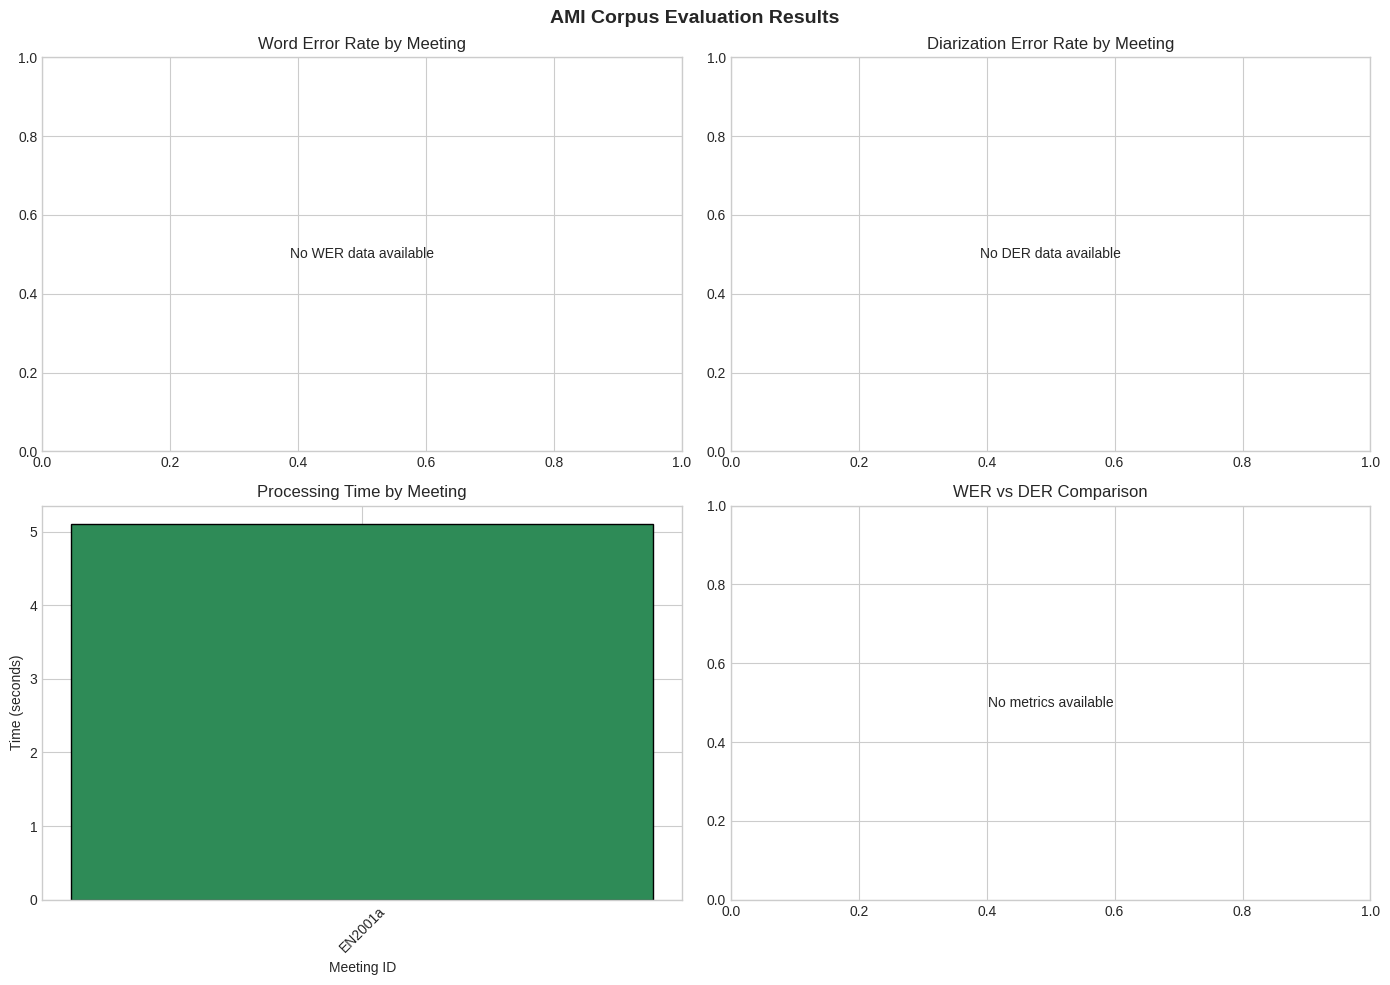

In [ ]:
# =============================================================================
# CELL 15: Visualization
# =============================================================================

def plot_evaluation_results(results_df: pd.DataFrame, output_dir: Path):
    """Generate visualization plots for evaluation results."""

    if results_df is None or results_df.empty:
        print("⚠️ No results to visualize")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('AMI Corpus Evaluation Results', fontsize=14, fontweight='bold')

    # 1. WER by Meeting
    ax1 = axes[0, 0]
    if 'wer' in results_df.columns and results_df['wer'].notna().any():
        bars = ax1.bar(results_df['meeting_id'], results_df['wer'], color='steelblue', edgecolor='black')
        ax1.axhline(y=results_df['wer'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["wer"].mean():.1f}%')
        ax1.set_xlabel('Meeting ID')
        ax1.set_ylabel('WER (%)')
        ax1.set_title('Word Error Rate by Meeting')
        ax1.legend()
        ax1.tick_params(axis='x', rotation=45)
    else:
        ax1.text(0.5, 0.5, 'No WER data available', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Word Error Rate by Meeting')

    # 2. DER by Meeting
    ax2 = axes[0, 1]
    if 'der' in results_df.columns and results_df['der'].notna().any():
        bars = ax2.bar(results_df['meeting_id'], results_df['der'], color='coral', edgecolor='black')
        ax2.axhline(y=results_df['der'].mean(), color='red', linestyle='--', label=f'Mean: {results_df["der"].mean():.1f}%')
        ax2.set_xlabel('Meeting ID')
        ax2.set_ylabel('DER (%)')
        ax2.set_title('Diarization Error Rate by Meeting')
        ax2.legend()
        ax2.tick_params(axis='x', rotation=45)
    else:
        ax2.text(0.5, 0.5, 'No DER data available', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Diarization Error Rate by Meeting')

    # 3. Processing Time
    ax3 = axes[1, 0]
    if 'processing_time_s' in results_df.columns:
        bars = ax3.bar(results_df['meeting_id'], results_df['processing_time_s'], color='seagreen', edgecolor='black')
        ax3.set_xlabel('Meeting ID')
        ax3.set_ylabel('Time (seconds)')
        ax3.set_title('Processing Time by Meeting')
        ax3.tick_params(axis='x', rotation=45)

    # 4. Summary - Error Rate Comparison
    ax4 = axes[1, 1]
    metrics = ['wer', 'der']
    available_metrics = [m for m in metrics if m in results_df.columns and results_df[m].notna().any()]

    if available_metrics:
        x = np.arange(len(results_df))
        width = 0.35

        for i, metric in enumerate(available_metrics):
            offset = width * (i - len(available_metrics)/2 + 0.5)
            bars = ax4.bar(x + offset, results_df[metric], width, label=metric.upper())

        ax4.set_xlabel('Meeting')
        ax4.set_ylabel('Error Rate (%)')
        ax4.set_title('WER vs DER Comparison')
        ax4.set_xticks(x)
        ax4.set_xticklabels(results_df['meeting_id'], rotation=45)
        ax4.legend()
    else:
        ax4.text(0.5, 0.5, 'No metrics available', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('WER vs DER Comparison')

    plt.tight_layout()

    # Save plot
    plot_path = output_dir / "evaluation_plots.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"📊 Plots saved: {plot_path}")

    plt.show()

    return fig

# Generate plots
if 'results_df' in dir() and results_df is not None:
    plot_evaluation_results(results_df, CONFIG["output_dir"])